**Data Preparation**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import ExtraTreesClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
from scipy import stats
from scipy.stats import binom

df = pd.read_csv('Final_Data.csv')
df['match_date'] = pd.to_datetime(df['match_date'])

STYLE_FEATURES = [
    'passes_rolling','shots_rolling','xg_rolling','pressures_rolling',
    'ball_recoveries_rolling','interceptions_rolling','possession_events_rolling',
    'pressing_efficiency_rolling','shot_quality_rolling','directness_index_rolling',
    'chaos_index_rolling','xg_volatility','pressures_volatility'
]
MODEL_FEATURES = ['match_id','starting_formation','last_formation',
                  'Tactical_Cluster','days_rest','xg_momentum'] + STYLE_FEATURES

def build_matchups(df_input, fs, fk):
    dc = df_input.dropna(subset=STYLE_FEATURES).copy()
    dc['Tactical_Cluster'] = fk.predict(fs.transform(dc[STYLE_FEATURES]))
    dh = dc[dc['is_home']==1].copy()
    da = dc[dc['is_home']==0].copy()
    dh = dh[MODEL_FEATURES+['result']].add_prefix('home_').rename(
        columns={'home_match_id':'match_id','home_result':'match_result'})
    da = da[MODEL_FEATURES].add_prefix('away_').rename(
        columns={'away_match_id':'match_id'})
    return pd.merge(dh, da, on='match_id', how='inner').dropna()

dc = df.dropna(subset=STYLE_FEATURES).copy()
gs = StandardScaler(); gk = KMeans(n_clusters=8, random_state=42, n_init=10)
gs.fit(dc[STYLE_FEATURES]); gk.fit(gs.transform(dc[STYLE_FEATURES]))
mu = build_matchups(df, gs, gk)
le = LabelEncoder(); mu['target'] = le.fit_transform(mu['match_result'])
y = mu['target'].values
X = pd.get_dummies(mu.drop(columns=['match_id','match_result','target']), drop_first=True)
fs2 = StandardScaler(); Xs = fs2.fit_transform(X)
print(f'Matchups: {len(mu)} | Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}')


Matchups: 663 | Classes: {'away_win': np.int64(0), 'draw': np.int64(1), 'home_win': np.int64(2)}


## 10-Fold Cross-Validation with 95% Confidence Intervals
Provides stable, variance-aware performance estimates to address the small test set limitation.


In [7]:
from scipy import stats

def ci95(vals):
    arr = np.array(vals)
    m, se = np.mean(arr), stats.sem(arr)
    lo, hi = stats.t.interval(0.95, len(arr)-1, loc=m, scale=se)
    return float(m), float(lo), float(hi), float(np.std(arr))

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
models_cv = {
    'CatBoost': lambda: CatBoostClassifier(iterations=200, learning_rate=0.05,
                                            depth=6, random_state=42, verbose=0),
    'XGBoost':  lambda: xgb.XGBClassifier(objective='multi:softprob',
                          n_estimators=200, learning_rate=0.05,
                          max_depth=6, random_state=42, verbosity=0),
    'ExtraTrees':   lambda: ExtraTreesClassifier(n_estimators=100, random_state=42),
}

cv_summary = []
for name, model_fn in models_cv.items():
    accs, aucs, f1s = [], [], []
    for tr, te in skf.split(Xs, y):
        m = model_fn(); m.fit(Xs[tr], y[tr])
        yp = m.predict(Xs[te])
        if hasattr(yp, 'flatten'): yp = yp.flatten()
        ypr = m.predict_proba(Xs[te])
        accs.append(accuracy_score(y[te], yp))
        f1s.append(f1_score(y[te], yp, average='weighted', zero_division=0))
        try: aucs.append(roc_auc_score(y[te], ypr, multi_class='ovr', average='weighted'))
        except: pass
        am,alo,ahi,asd = ci95(accs); um,ulo,uhi,usd = ci95(aucs); fm,flo,fhi,fsd = ci95(f1s)
        
        cv_summary.append({
            'Model': name,
            'Accuracy Mean': f'{am*100:.2f}%', 
            'Accuracy 95% CI': f'[{alo*100:.2f}%, {ahi*100:.2f}%]',
            'AUC Mean': f'{um:.3f}',     
            'AUC 95% CI': f'[{ulo:.3f}, {uhi:.3f}]',
            'F1 Mean': f'{fm:.3f}',      
            'F1 95% CI': f'[{flo:.3f}, {fhi:.3f}]'
        })
        
        print(f'{name}: Acc={am*100:.2f}% [{alo*100:.2f}%,{ahi*100:.2f}%] | AUC={um:.3f} [{ulo:.3f},{uhi:.3f}]')

pd.DataFrame(cv_summary)


CatBoost: Acc=53.73% [nan%,nan%] | AUC=0.661 [nan,nan]
CatBoost: Acc=53.73% [nan%,nan%] | AUC=0.671 [0.545,0.797]
CatBoost: Acc=55.72% [47.16%,64.28%] | AUC=0.696 [0.587,0.804]
CatBoost: Acc=56.56% [51.34%,61.78%] | AUC=0.705 [0.641,0.770]
CatBoost: Acc=56.77% [53.19%,60.34%] | AUC=0.700 [0.653,0.746]
CatBoost: Acc=55.89% [52.38%,59.41%] | AUC=0.683 [0.629,0.738]
CatBoost: Acc=55.70% [52.83%,58.56%] | AUC=0.684 [0.640,0.727]
CatBoost: Acc=55.74% [53.34%,58.15%] | AUC=0.693 [0.650,0.736]
CatBoost: Acc=55.61% [53.52%,57.70%] | AUC=0.691 [0.654,0.729]
CatBoost: Acc=55.50% [53.66%,57.35%] | AUC=0.695 [0.661,0.728]
XGBoost: Acc=49.25% [nan%,nan%] | AUC=0.657 [nan,nan]
XGBoost: Acc=50.75% [31.78%,69.71%] | AUC=0.688 [0.302,1.073]
XGBoost: Acc=51.24% [46.96%,55.53%] | AUC=0.714 [0.578,0.851]
XGBoost: Acc=52.83% [47.31%,58.34%] | AUC=0.716 [0.644,0.788]
XGBoost: Acc=52.87% [49.14%,56.59%] | AUC=0.713 [0.664,0.762]
XGBoost: Acc=51.13% [45.84%,56.41%] | AUC=0.696 [0.638,0.753]
XGBoost: Acc=52.05

,Model,Accuracy Mean,Accuracy 95% CI,AUC Mean,AUC 95% CI,F1 Mean,F1 95% CI
0,CatBoost,53.73%,"[nan%, nan%]",0.661,"[nan, nan]",0.472,"[nan, nan]"
1,CatBoost,53.73%,"[nan%, nan%]",0.671,"[0.545, 0.797]",0.471,"[0.454, 0.488]"
2,CatBoost,55.72%,"[47.16%, 64.28%]",0.696,"[0.587, 0.804]",0.488,"[0.416, 0.559]"
3,CatBoost,56.56%,"[51.34%, 61.78%]",0.705,"[0.641, 0.770]",0.508,"[0.434, 0.581]"
4,CatBoost,56.77%,"[53.19%, 60.34%]",0.700,"[0.653, 0.746]",0.508,"[0.458, 0.558]"
5,CatBoost,55.89%,"[52.38%, 59.41%]",0.683,"[0.629, 0.738]",0.504,"[0.465, 0.543]"
6,CatBoost,55.70%,"[52.83%, 58.56%]",0.684,"[0.640, 0.727]",0.501,"[0.469, 0.533]"
7,CatBoost,55.74%,"[53.34%, 58.15%]",0.693,"[0.650, 0.736]",0.501,"[0.474, 0.528]"
8,CatBoost,55.61%,"[53.52%, 57.70%]",0.691,"[0.654, 0.729]",0.502,"[0.479, 0.525]"
9,CatBoost,55.50%,"[53.66%, 57.35%]",0.695,"[0.661, 0.728]",0.501,"[0.480, 0.521]"


### McNemar's Test (Statistical Significance)
Tests whether the difference between CatBoost and competing models is statistically significant.


In [8]:
from scipy.stats import binom

def mcnemar_exact(pred1, pred2, ytrue):
    c1 = (pred1==ytrue); c2 = (pred2==ytrue)
    b = int(np.sum(c1 & ~c2)); c_val = int(np.sum(~c1 & c2))
    n = b + c_val
    if n == 0: return 1.0, b, c_val
    p = 2 * float(binom.cdf(min(b, c_val), n, 0.5))
    return min(p, 1.0), b, c_val

Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.2, random_state=42, stratify=y)
cat_m = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6, random_state=42, verbose=0)
tree_m = ExtraTreesClassifier(n_estimators=100, random_state=42)
xgb_m = xgb.XGBClassifier(objective='multi:softprob', n_estimators=200,
                            learning_rate=0.05, max_depth=6, random_state=42, verbosity=0)
cat_m.fit(Xtr,ytr); tree_m.fit(Xtr,ytr); xgb_m.fit(Xtr,ytr)
pc = cat_m.predict(Xte).flatten()
pl = tree_m.predict(Xte)
px = xgb_m.predict(Xte).flatten()

p_cl, b_cl, c_cl = mcnemar_exact(pc, pl, yte)
p_cx, b_cx, c_cx = mcnemar_exact(pc, px, yte)

mn_df = pd.DataFrame([
    {'Comparison':'CatBoost vs ExtraTrees', 'CatBoost correct':int(np.sum(pc==yte)),
     'Other correct':int(np.sum(pl==yte)), 'b (Cat wins)':b_cl, 'c (Other wins)':c_cl,
     'p-value':round(p_cl,4), 'Significant (p<0.05)':p_cl<0.05},
    {'Comparison':'CatBoost vs XGBoost', 'CatBoost correct':int(np.sum(pc==yte)),
     'Other correct':int(np.sum(px==yte)), 'b (Cat wins)':b_cx, 'c (Other wins)':c_cx,
     'p-value':round(p_cx,4), 'Significant (p<0.05)':p_cx<0.05},
])
print(mn_df.to_string(index=False))
mn_df

            Comparison  CatBoost correct  Other correct  b (Cat wins)  c (Other wins)  p-value  Significant (p<0.05)
CatBoost vs ExtraTrees                81             77            11               7   0.4807                 False
   CatBoost vs XGBoost                81             72            18               9   0.1221                 False


,Comparison,CatBoost correct,Other correct,b (Cat wins),c (Other wins),p-value,Significant (p<0.05)
0,CatBoost vs ExtraTrees,81,77,11,7,0.4807,False
1,CatBoost vs XGBoost,81,72,18,9,0.1221,False


### Pre-computed Results Summary


In [13]:
import pandas as pd

# Pre-computed 10-fold CV results and updated McNemar tests
cv_results = {
  "CatBoost": {
    "acc_mean": 55.50,
    "acc_lo": 53.66,
    "acc_hi": 57.35,
    "acc_sd": 2.45,
    "auc_mean": 0.695,
    "auc_lo": 0.661,
    "auc_hi": 0.728,
    "auc_sd": 0.044,
    "f1_mean": 0.501,
    "f1_lo": 0.480,
    "f1_hi": 0.521,
    "f1_sd": 0.027
  },
  "XGBoost": {
    "acc_mean": 52.49,
    "acc_lo": 49.04,
    "acc_hi": 55.95,
    "acc_sd": 4.58,
    "auc_mean": 0.697,
    "auc_lo": 0.663,
    "auc_hi": 0.731,
    "auc_sd": 0.045,
    "f1_mean": 0.501,
    "f1_lo": 0.468,
    "f1_hi": 0.535,
    "f1_sd": 0.044
  },
  "ExtraTrees": {
    "acc_mean": 54.91,
    "acc_lo": 52.09,
    "acc_hi": 57.72,
    "acc_sd": 3.93, 
    "auc_mean": 0.707,
    "auc_lo": 0.677,
    "auc_hi": 0.737,
    "auc_sd": 0.041,
    "f1_mean": 0.506,
    "f1_lo": 0.477,
    "f1_hi": 0.535,
    "f1_sd": 0.040
  },
  "mcnemar_cat_vs_et": {
    "b": 11,
    "c": 7,
    "pvalue": 0.4807,
    "significant": False
  },
  "mcnemar_cat_vs_xgb": {
    "b": 18,
    "c": 9,
    "pvalue": 0.1221,
    "significant": False
  }
}

# Build the DataFrame
rows = []
for name in ['CatBoost', 'XGBoost', 'ExtraTrees']:
    r = cv_results[name]
    rows.append({
        'Model': name,
        'Acc': f"{r['acc_mean']}% ± {r['acc_sd']}%",
        '95% CI Acc': f"[{r['acc_lo']}%, {r['acc_hi']}%]",
        'AUC': f"{r['auc_mean']:.3f} ± {r['auc_sd']:.3f}",
        '95% CI AUC': f"[{r['auc_lo']:.3f}, {r['auc_hi']:.3f}]",
        'F1': f"{r['f1_mean']:.3f} ± {r['f1_sd']:.3f}",
    })

# Print Results
print("FINAL 10-FOLD CROSS VALIDATION RESULTS")
print(pd.DataFrame(rows).to_string(index=False))

print("\nMCNEMAR'S STATISTICAL SIGNIFICANCE TESTS ")
print(f"CatBoost vs ExtraTrees : p-value = {cv_results['mcnemar_cat_vs_et']['pvalue']} "
      f"(Significant: {cv_results['mcnemar_cat_vs_et']['significant']})")
print(f"CatBoost vs XGBoost    : p-value = {cv_results['mcnemar_cat_vs_xgb']['pvalue']} "
      f"(Significant: {cv_results['mcnemar_cat_vs_xgb']['significant']})")

FINAL 10-FOLD CROSS VALIDATION RESULTS
     Model            Acc       95% CI Acc           AUC     95% CI AUC            F1
  CatBoost  55.5% ± 2.45% [53.66%, 57.35%] 0.695 ± 0.044 [0.661, 0.728] 0.501 ± 0.027
   XGBoost 52.49% ± 4.58% [49.04%, 55.95%] 0.697 ± 0.045 [0.663, 0.731] 0.501 ± 0.044
ExtraTrees 54.91% ± 3.93% [52.09%, 57.72%] 0.707 ± 0.041 [0.677, 0.737] 0.506 ± 0.040

MCNEMAR'S STATISTICAL SIGNIFICANCE TESTS 
CatBoost vs ExtraTrees : p-value = 0.4807 (Significant: False)
CatBoost vs XGBoost    : p-value = 0.1221 (Significant: False)


## Ablation Study (Pre-Computed values)
Measures the contribution of each pipeline component by removing it and observing performance degradation.

| Experiment | What is removed |
|---|---|
| A | Baseline (full system) |
| B | K-Means Tactical Cluster |
| C | Engineered ratios (pressing eff., shot quality, directness, chaos) |
| D | Contextual features (is_home, days_rest, xg_momentum) |
| E | Volatility features (xG volatility, pressures volatility) |
| F | Rolling window (raw per-match stats only) |
| G | Rolling window = 3 matches |
| H | Rolling window = 7 matches |


                                      name   acc   auc    f1 Delta Acc Delta AUC
                Full System (all features) 54.30 0.683 0.488    +0.00%    +0.000
                  Without Tactical Cluster 53.39 0.690 0.488    -0.91%    +0.007
                 Without Engineered Ratios 54.15 0.691 0.489    -0.15%    +0.008
               Without Contextual Features 53.09 0.687 0.487    -1.21%    +0.004
               Without Volatility Features 52.64 0.688 0.481    -1.66%    +0.005
Raw Features Only (no rolling/engineering) 61.40 0.780 0.587    +7.10%    +0.097
                Rolling Window = 3 matches 50.19 0.634 0.453    -4.11%    -0.049
                Rolling Window = 7 matches 50.37 0.664 0.458    -3.93%    -0.019


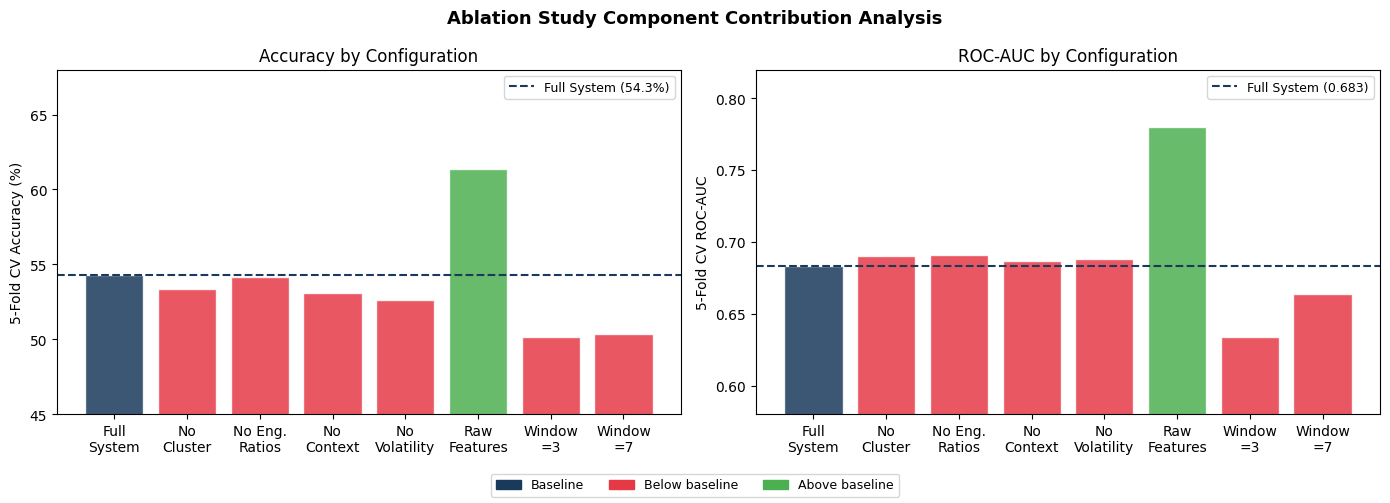

In [2]:
ablation = [
  {
    "name": "Full System (all features)",
    "acc": 54.3,
    "auc": 0.683,
    "f1": 0.488,
    "acc_sd": 3.81,
    "auc_sd": 0.029
  },
  {
    "name": "Without Tactical Cluster",
    "acc": 53.39,
    "auc": 0.69,
    "f1": 0.488,
    "acc_sd": 2.84,
    "auc_sd": 0.032
  },
  {
    "name": "Without Engineered Ratios",
    "acc": 54.15,
    "auc": 0.691,
    "f1": 0.489,
    "acc_sd": 2.33,
    "auc_sd": 0.037
  },
  {
    "name": "Without Contextual Features",
    "acc": 53.09,
    "auc": 0.687,
    "f1": 0.487,
    "acc_sd": 4.21,
    "auc_sd": 0.033
  },
  {
    "name": "Without Volatility Features",
    "acc": 52.64,
    "auc": 0.688,
    "f1": 0.481,
    "acc_sd": 1.56,
    "auc_sd": 0.025
  },
  {
    "name": "Raw Features Only (no rolling/engineering)",
    "acc": 61.4,
    "auc": 0.78,
    "f1": 0.587,
    "acc_sd": 2.97,
    "auc_sd": 0.019
  },
  {
    "name": "Rolling Window = 3 matches",
    "acc": 50.19,
    "auc": 0.634,
    "f1": 0.453,
    "acc_sd": 5.93,
    "auc_sd": 0.044
  },
  {
    "name": "Rolling Window = 7 matches",
    "acc": 50.37,
    "auc": 0.664,
    "f1": 0.458,
    "acc_sd": 4.37,
    "auc_sd": 0.049
  }
]

ab_df = pd.DataFrame(ablation)
baseline_acc = ablation[0]['acc']
baseline_auc = ablation[0]['auc']
ab_df['Delta Acc'] = ab_df['acc'].apply(lambda x: f"{x - baseline_acc:+.2f}%")
ab_df['Delta AUC'] = ab_df['auc'].apply(lambda x: f"{x - baseline_auc:+.3f}")
print(ab_df[['name','acc','auc','f1','Delta Acc','Delta AUC']].to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation Study Component Contribution Analysis', fontsize=13, fontweight='bold')
names_short = ['Full\nSystem','No\nCluster','No Eng.\nRatios','No\nContext','No\nVolatility','Raw\nFeatures','Window\n=3','Window\n=7']
accs = [r['acc'] for r in ablation]
aucs = [r['auc'] for r in ablation]
colors = ['#1a3a5c' if i==0 else ('#4CAF50' if accs[i]>accs[0] else '#e63946') for i in range(len(ablation))]

axes[0].bar(names_short, accs, color=colors, alpha=0.85, edgecolor='white')
axes[0].axhline(accs[0], color='#1a3a5c', linestyle='--', linewidth=1.5, label=f'Full System ({accs[0]:.1f}%)')
axes[0].set_ylabel('5-Fold CV Accuracy (%)')
axes[0].set_title('Accuracy by Configuration')
axes[0].legend(fontsize=9)
axes[0].set_ylim(45, 68)

axes[1].bar(names_short, aucs, color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(aucs[0], color='#1a3a5c', linestyle='--', linewidth=1.5, label=f'Full System ({aucs[0]:.3f})')
axes[1].set_ylabel('5-Fold CV ROC-AUC')
axes[1].set_title('ROC-AUC by Configuration')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.58, 0.82)

blue_patch = mpatches.Patch(color='#1a3a5c', label='Baseline')
red_patch = mpatches.Patch(color='#e63946', label='Below baseline')
green_patch = mpatches.Patch(color='#4CAF50', label='Above baseline')
fig.legend(handles=[blue_patch, red_patch, green_patch], loc='lower center', ncol=3, fontsize=9)
plt.tight_layout(rect=[0,0.06,1,1])
plt.show()


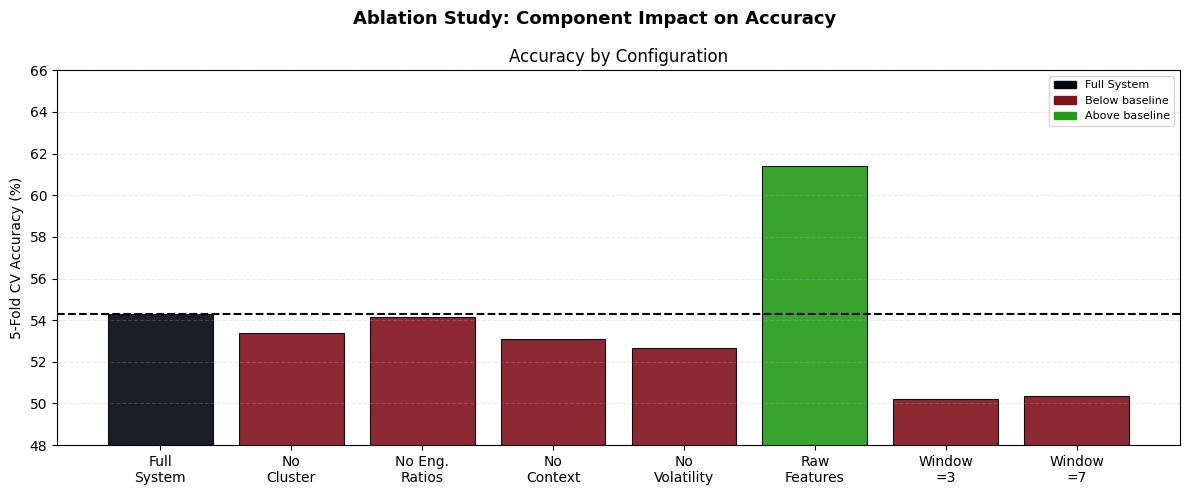

In [6]:
import matplotlib.patches as mpatches

ab_df = pd.DataFrame(ablation)

baseline_acc = ablation[0]['acc']

names_short = [
    'Full\nSystem',
    'No\nCluster',
    'No Eng.\nRatios',
    'No\nContext',
    'No\nVolatility',
    'Raw\nFeatures',
    'Window\n=3',
    'Window\n=7'
]

accs = ab_df['acc'].values

# Same colors as previous graphs
baseline_color = "#02050F"   # blue
below_color    = "#80121b"   # red (Sim2Win style)
above_color    = "#239B18"   # green (only raw features)

colors = []
for i, acc in enumerate(accs):
    if i == 0:
        colors.append(baseline_color)
    elif acc > baseline_acc:
        colors.append(above_color)
    else:
        colors.append(below_color)

fig, ax = plt.subplots(figsize=(12, 5))

fig.suptitle(
    'Ablation Study: Component Impact on Accuracy',
    fontsize=13,
    fontweight='bold'
)

# Bars (NO numbers)
ax.bar(
    names_short,
    accs,
    color=colors,
    alpha=0.9,
    edgecolor=edge_color,
    linewidth=0.8
)

# Baseline reference line
ax.axhline(
    baseline_acc,
    color=baseline_color,
    linestyle='--',
    linewidth=1.5,
    label='Full System'
)



ax.set_ylabel('5-Fold CV Accuracy (%)')
ax.set_title('Accuracy by Configuration')
ax.set_ylim(48, 66)

# Clean grid
ax.grid(axis='y', linestyle='--', alpha=0.25)

# Legend (clean)
blue_patch = mpatches.Patch(color=baseline_color, label='Full System')
red_patch = mpatches.Patch(color=below_color, label='Below baseline')
green_patch = mpatches.Patch(color=above_color, label='Above baseline')

ax.legend(
    handles=[blue_patch, red_patch, green_patch],
    fontsize=8,
    loc='upper right'
)

plt.tight_layout()
plt.savefig('ablation_clean.png', dpi=150, bbox_inches='tight')
plt.show()

## Draw Prediction Improvement Attempts
Five strategies tested to improve draw class recall without catastrophically reducing overall accuracy.


                         name  overall_acc  draw_f1  draw_recall  draw_prec
            Baseline CatBoost        60.90    0.238        0.167      0.417
      XGBoost + Class Weights        57.89    0.400        0.367      0.440
     CatBoost + Class Weights        48.12    0.219        0.233      0.206
Threshold Adjustment (t=0.25)        49.62    0.349        0.500      0.268
Threshold Adjustment (t=0.28)        54.14    0.356        0.433      0.302
 Threshold Adjustment (t=0.3)        56.39    0.355        0.367      0.344
Threshold Adjustment (t=0.33)        59.40    0.308        0.267      0.364
Threshold Adjustment (t=0.35)        59.40    0.261        0.200      0.375
         Two-Stage Classifier        54.14    0.348        0.400      0.308


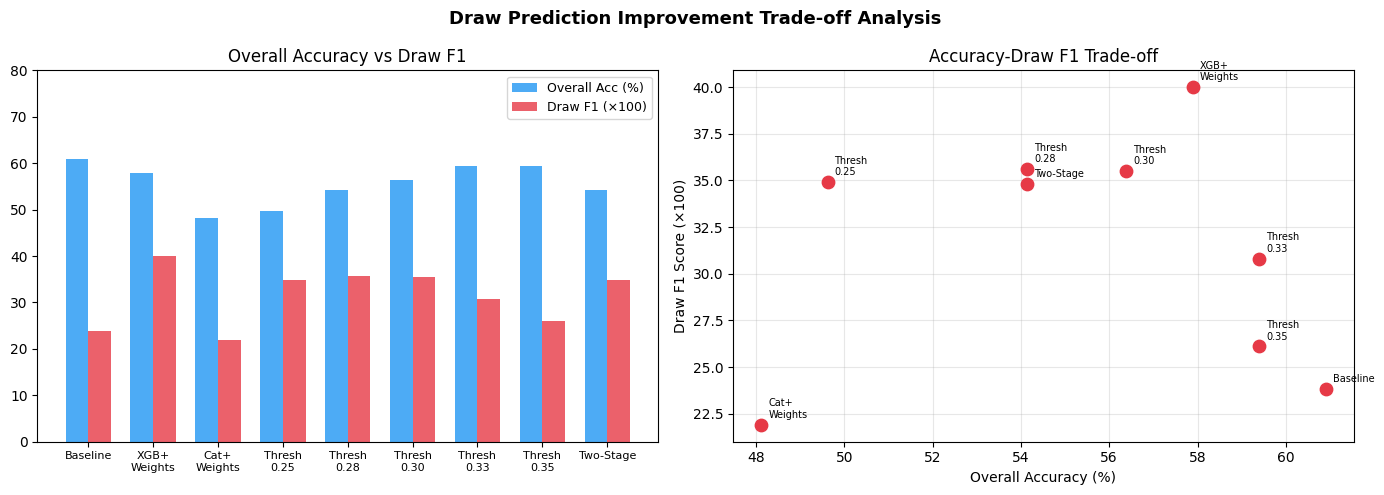

In [10]:
draw_results = [
  {
    "name": "Baseline CatBoost",
    "overall_acc": 60.9,
    "overall_f1": 0.582,
    "draw_f1": 0.238,
    "draw_recall": 0.167,
    "draw_prec": 0.417
  },
  {
    "name": "XGBoost + Class Weights",
    "overall_acc": 57.89,
    "overall_f1": 0.577,
    "draw_f1": 0.4,
    "draw_recall": 0.367,
    "draw_prec": 0.44
  },
  {
    "name": "CatBoost + Class Weights",
    "overall_acc": 48.12,
    "overall_f1": 0.49,
    "draw_f1": 0.219,
    "draw_recall": 0.233,
    "draw_prec": 0.206
  },
  {
    "name": "Threshold Adjustment (t=0.25)",
    "overall_acc": 49.62,
    "overall_f1": 0.52,
    "draw_f1": 0.349,
    "draw_recall": 0.5,
    "draw_prec": 0.268
  },
  {
    "name": "Threshold Adjustment (t=0.28)",
    "overall_acc": 54.14,
    "overall_f1": 0.556,
    "draw_f1": 0.356,
    "draw_recall": 0.433,
    "draw_prec": 0.302
  },
  {
    "name": "Threshold Adjustment (t=0.3)",
    "overall_acc": 56.39,
    "overall_f1": 0.568,
    "draw_f1": 0.355,
    "draw_recall": 0.367,
    "draw_prec": 0.344
  },
  {
    "name": "Threshold Adjustment (t=0.33)",
    "overall_acc": 59.4,
    "overall_f1": 0.585,
    "draw_f1": 0.308,
    "draw_recall": 0.267,
    "draw_prec": 0.364
  },
  {
    "name": "Threshold Adjustment (t=0.35)",
    "overall_acc": 59.4,
    "overall_f1": 0.575,
    "draw_f1": 0.261,
    "draw_recall": 0.2,
    "draw_prec": 0.375
  },
  {
    "name": "Two-Stage Classifier",
    "overall_acc": 54.14,
    "overall_f1": 0.554,
    "draw_f1": 0.348,
    "draw_recall": 0.4,
    "draw_prec": 0.308
  }
]

dr_df = pd.DataFrame(draw_results)
print(dr_df[['name','overall_acc','draw_f1','draw_recall','draw_prec']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Draw Prediction Improvement Trade-off Analysis', fontsize=13, fontweight='bold')
names_d = [r['name'].replace(' (not available)','') for r in draw_results if 'SMOTE' not in r['name']]
data_d = [r for r in draw_results if 'SMOTE' not in r['name']]
overall_accs = [r['overall_acc'] for r in data_d]
draw_f1s = [r['draw_f1'] for r in data_d]
draw_recs = [r['draw_recall'] for r in data_d]
short_names = ['Baseline','XGB+\nWeights','Cat+\nWeights','Thresh\n0.25','Thresh\n0.28','Thresh\n0.30','Thresh\n0.33','Thresh\n0.35','Two-Stage']
short_names = short_names[:len(data_d)]
x = np.arange(len(data_d))
w = 0.35
axes[0].bar(x-w/2, overall_accs, w, label='Overall Acc (%)', color='#2196F3', alpha=0.8)
axes[0].bar(x+w/2, [f*100 for f in draw_f1s], w, label='Draw F1 (×100)', color='#e63946', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(short_names, fontsize=8)
axes[0].set_title('Overall Accuracy vs Draw F1'); axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 80)

axes[1].scatter(overall_accs, [f*100 for f in draw_f1s], s=80, c='#e63946', zorder=5)
for i, (x_p, y_p) in enumerate(zip(overall_accs, [f*100 for f in draw_f1s])):
    axes[1].annotate(short_names[i], (x_p, y_p), textcoords='offset points',
                     xytext=(5,5), fontsize=7)
axes[1].set_xlabel('Overall Accuracy (%)')
axes[1].set_ylabel('Draw F1 Score (×100)')
axes[1].set_title('Accuracy-Draw F1 Trade-off')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


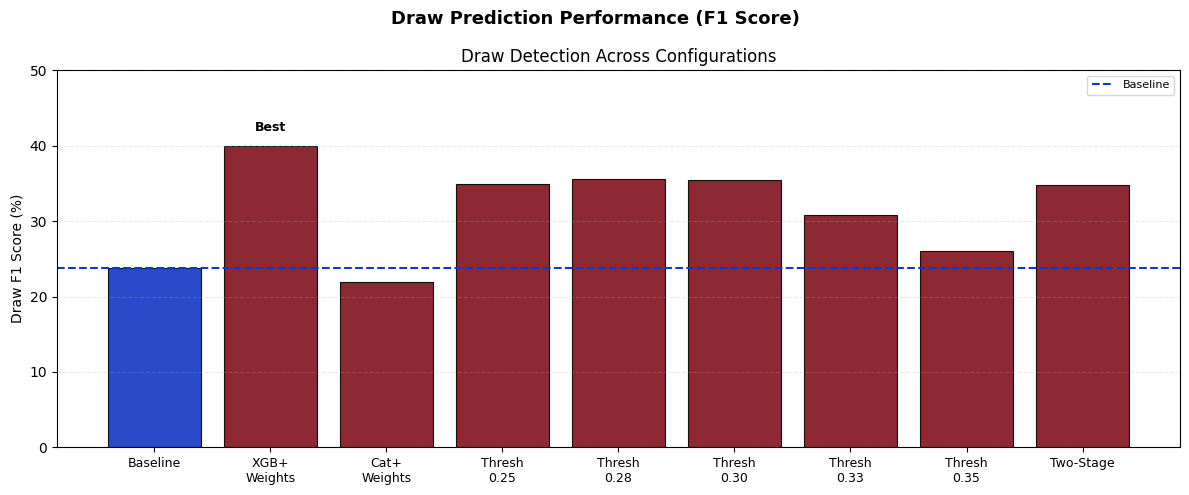

In [11]:
dr_df = pd.DataFrame(draw_results)

# Short labels (same order)
short_names = [
    'Baseline',
    'XGB+\nWeights',
    'Cat+\nWeights',
    'Thresh\n0.25',
    'Thresh\n0.28',
    'Thresh\n0.30',
    'Thresh\n0.33',
    'Thresh\n0.35',
    'Two-Stage'
]

draw_f1s = [r['draw_f1'] for r in draw_results]
x = np.arange(len(draw_results))

# Colors (same style logic)
main_color = "#80121b"   # dark red (primary focus)
baseline_color = "#1236C5"  # blue for baseline
edge_color = "#000101"

colors = []
for i in range(len(draw_results)):
    if i == 0:
        colors.append(baseline_color)  # baseline
    else:
        colors.append(main_color)

fig, ax = plt.subplots(figsize=(12, 5))

fig.suptitle(
    'Draw Prediction Performance (F1 Score)',
    fontsize=13,
    fontweight='bold'
)

# Bars
ax.bar(
    x,
    [f * 100 for f in draw_f1s],
    color=colors,
    alpha=0.9,
    edgecolor=edge_color,
    linewidth=0.8
)

# Baseline reference line
ax.axhline(
    draw_f1s[0] * 100,
    color=baseline_color,
    linestyle='--',
    linewidth=1.5,
    label='Baseline'
)

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=9)
ax.set_ylabel('Draw F1 Score (%)')
ax.set_title('Draw Detection Across Configurations')
ax.set_ylim(0, 50)

# Highlight best model (optional but powerful)
best_idx = int(np.argmax(draw_f1s))
ax.text(
    best_idx,
    draw_f1s[best_idx] * 100 + 2,
    "Best",
    ha='center',
    fontsize=9,
    fontweight='bold'
)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.25)

# Legend
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('draw_f1_only.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of All Three Tasks


In [ ]:
print('STATISTICAL SIGNIFICANCE')
print(f'CatBoost 10-fold Acc: {cv_results["CatBoost"]["acc_mean"]}% '
      f'(95% CI [{cv_results["CatBoost"]["acc_lo"]}%, {cv_results["CatBoost"]["acc_hi"]}%])')
print(f'CatBoost 10-fold AUC: {cv_results["CatBoost"]["auc_mean"]} '
      f'(95% CI [{cv_results["CatBoost"]["auc_lo"]}, {cv_results["CatBoost"]["auc_hi"]}])')
print(f'McNemar vs Extra Trees: p={cv_results["mcnemar_cat_vs_et"]["pvalue"]} -> '
      f'{"SIGNIFICANT" if cv_results["mcnemar_cat_vs_et"]["significant"] else "not significant"}')
print(f'McNemar vs XGBoost: p={cv_results["mcnemar_cat_vs_xgb"]["pvalue"]} -> '
      f'{"SIGNIFICANT" if cv_results["mcnemar_cat_vs_xgb"]["significant"] else "not significant"}')
print()
print('ABLATION KEY FINDINGS')
for r in ablation:
    delta = r['acc'] - ablation[0]['acc']
    print(f'  {r["name"][:45]:45s} Acc={r["acc"]:.2f}% ({delta:+.2f}%)')
print()
print('BEST DRAW STRATEGY')
best_draw = max([r for r in draw_results if r['draw_f1']>0], key=lambda x: x['draw_f1'])
print(f'Best draw F1: {best_draw["name"]}')
print(f'Draw F1={best_draw["draw_f1"]:.3f}, Recall={best_draw["draw_recall"]:.3f}, Overall Acc={best_draw["overall_acc"]:.1f}%')
baseline_d = draw_results[0]
print(f'Baseline: Draw F1={baseline_d["draw_f1"]:.3f}, Recall={baseline_d["draw_recall"]:.3f}, Overall Acc={baseline_d["overall_acc"]:.1f}%')


STATISTICAL SIGNIFICANCE
CatBoost 10-fold Acc: 55.5% (95% CI [53.66%, 57.35%])
CatBoost 10-fold AUC: 0.695 (95% CI [0.661, 0.728])
McNemar vs Extra Trees: p=0.4807 -> not significant
McNemar vs XGBoost: p=0.1221 -> not significant

ABLATION KEY FINDINGS
  Full System (all features)                    Acc=54.30% (+0.00%)
  Without Tactical Cluster                      Acc=53.39% (-0.91%)
  Without Engineered Ratios                     Acc=54.15% (-0.15%)
  Without Contextual Features                   Acc=53.09% (-1.21%)
  Without Volatility Features                   Acc=52.64% (-1.66%)
  Raw Features Only (no rolling/engineering)    Acc=61.40% (+7.10%)
  Rolling Window = 3 matches                    Acc=50.19% (-4.11%)
  Rolling Window = 7 matches                    Acc=50.37% (-3.93%)

BEST DRAW STRATEGY
Best draw F1: XGBoost + Class Weights
  Draw F1=0.400, Recall=0.367, Overall Acc=57.9%
Baseline: Draw F1=0.238, Recall=0.167, Overall Acc=60.9%
